In [1]:
import pandas as pd
import sqlite3
import numpy as np

print("SQL project started")

SQL project started


In [2]:
np.random.seed(42)

data = {
    'Sample_ID': range(1, 201),
    'Test_Type': np.random.choice(['Endotoxin', 'Bioburden'], 200),
    'Analyst': np.random.choice(['Analyst_A', 'Analyst_B', 'Analyst_C'], 200),
    'Instrument': np.random.choice(['HPLC_1', 'HPLC_2', 'HPLC_3'], 200),
    'Result': np.round(np.random.normal(0.04, 0.015, 200), 3),
    'Test_Date': pd.date_range(start='2025-01-01', periods=200, freq='D')
}


df = pd.DataFrame(data)

# Create Pass/Fail column
df['Status'] = np.where(df['Result'] <= 0.05, 'Pass', 'Fail')

# View first rows
df.head()


,Sample_ID,Test_Type,Analyst,Instrument,Result,Test_Date,Status
0,1,Endotoxin,Analyst_C,HPLC_1,0.054,2025-01-01,Fail
1,2,Bioburden,Analyst_C,HPLC_2,0.062,2025-01-02,Fail
2,3,Endotoxin,Analyst_A,HPLC_1,0.045,2025-01-03,Pass
3,4,Endotoxin,Analyst_A,HPLC_3,0.049,2025-01-04,Pass
4,5,Endotoxin,Analyst_B,HPLC_3,0.031,2025-01-05,Pass


In [3]:
# Create SQLite database connection

conn = sqlite3.connect('lab_qc.db')

# Load dataframe into SQL table
df.to_sql('lab_results', conn, if_exists='replace', index=False)

print("SQL database created successfully")

SQL database created successfully


In [4]:
# SQL Query 1
# Count Pass vs Fail results

query = """
SELECT Status, COUNT(*) AS Count
FROM lab_results
GROUP BY Status
"""

result = pd.read_sql_query(query, conn)

result

,Status,Count
0,Fail,61
1,Pass,139


In [5]:
# SQL Query 2
# Failures by Test Type

query2 = """
SELECT Test_Type,
       COUNT(*) AS Total_Tests,
       SUM(CASE WHEN Status = 'Fail' THEN 1 ELSE 0 END) AS Fail_Count
FROM lab_results
GROUP BY Test_Type
"""

result2 = pd.read_sql_query(query2, conn)

result2

,Test_Type,Total_Tests,Fail_Count
0,Bioburden,100,33
1,Endotoxin,100,28


In [6]:
# SQL Query 3
# Failure count by Analyst

query3 = """
SELECT Analyst,
       COUNT(*) AS Total_Tests,
       SUM(CASE WHEN Status = 'Fail' THEN 1 ELSE 0 END) AS Fail_Count
FROM lab_results
GROUP BY Analyst
ORDER BY Fail_Count DESC
"""

result3 = pd.read_sql_query(query3, conn)

result3

,Analyst,Total_Tests,Fail_Count
0,Analyst_A,73,27
1,Analyst_C,66,17
2,Analyst_B,61,17


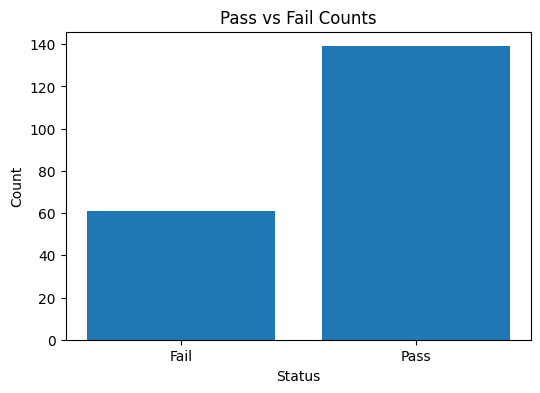

In [7]:
import matplotlib.pyplot as plt

# Create bar chart

plt.figure(figsize=(6,4))

plt.bar(result['Status'], result['Count'])

plt.title('Pass vs Fail Counts')
plt.xlabel('Status')
plt.ylabel('Count')

plt.show()

In [8]:
# Final project summary

print("Laboratory SQL QC Analysis Completed")

print("\nKey Findings:")
print("- Total Pass Results:", result[result['Status']=='Pass']['Count'].values[0])
print("- Total Fail Results:", result[result['Status']=='Fail']['Count'].values[0])

print("\nBioburden had slightly more failures than Endotoxin.")
print("Analyst_A showed the highest number of failures.")

Laboratory SQL QC Analysis Completed

Key Findings:
- Total Pass Results: 139
- Total Fail Results: 61

Bioburden had slightly more failures than Endotoxin.
Analyst_A showed the highest number of failures.


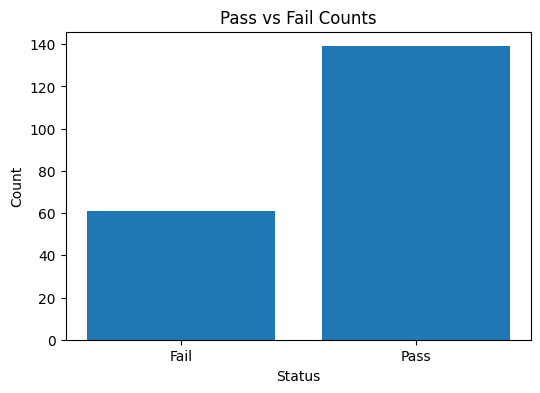

In [9]:
# Save chart as PNG

plt.figure(figsize=(6,4))

plt.bar(result['Status'], result['Count'])

plt.title('Pass vs Fail Counts')
plt.xlabel('Status')
plt.ylabel('Count')

plt.savefig('sql_pass_fail_counts.png')

plt.show()

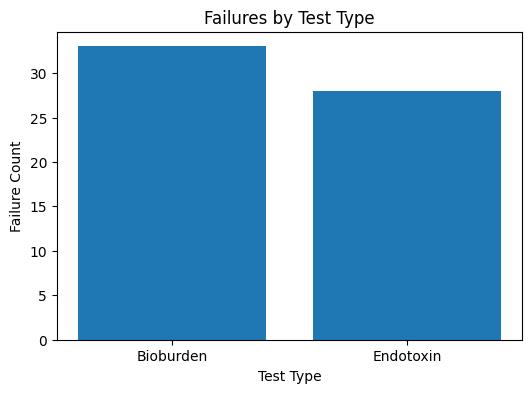

In [10]:
# Failures by Test Type chart

plt.figure(figsize=(6,4))

plt.bar(result2['Test_Type'], result2['Fail_Count'])

plt.title('Failures by Test Type')
plt.xlabel('Test Type')
plt.ylabel('Failure Count')

plt.savefig('sql_failures_by_test_type.png')

plt.show()